In [1]:
%reload_ext autoreload
%autoreload 2

import brian2 as b2
import brian2hears as b2h
import sys, os
# Compute the project root automatically
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(PROJECT_ROOT)
simulate_repo = PROJECT_ROOT + '/simulate'
print(simulate_repo)
sys.path.insert(0, simulate_repo)

from simulate.models.BrainstemModel.params import Parameters as params
from utils.anf_utils import ZI_COC_KEY, create_sound_key
from utils.hrtf_utils import run_hrtf
from utils.custom_sounds import Click, Tone, WhiteNoise, Click_Train
from utils.cochlea_utils import ANGLES
from analyze.report import plot_sound
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams["axes.grid"] = True
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.titleweight']= 'bold'
plt.rcParams['axes.spines.top']= False
plt.rcParams['axes.labelsize'] = 14 
plt.rcParams['xtick.labelsize'] = 12   # Size of x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12   # Size of y-axis tick labels
plt.rcParams['legend.fontsize'] = 14   # Size of the legend text
# Make axis labels bold
plt.rcParams['axes.labelweight'] = 'bold'  # Makes x and y axis labels bold



/Users/francescodesantis/Documents/repos/sound_localization_model
/Users/francescodesantis/Documents/repos/sound_localization_model/simulate
2025-12-03 11:49:25,673 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}




              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
TIME_SIMULATION = 250
level = 80 * b2h.dB

inputs = [
    Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(1.2 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(4 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(16 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    WhiteNoise(TIME_SIMULATION * b2.ms, level),
]
inputs_2 = [Click(duration= TIME_SIMULATION * b2.ms, click_duration=1, level=level),
            Click_Train(duration= TIME_SIMULATION * b2.ms, click_duration=1 * b2.ms, interval=4 * b2.ms, level=level)]

In [3]:
p = params()
print(p)

Parameters(key='default_params', cochlea={'gammatone': {'hrtf_params': {'subj_number': 0, 'ild_only': False, 'itd_remove_strategy': 'computed', 'apply_gating': True, 'ramp_ms': 10}, 'noise_factor': 0.3, 'refractory_period': 1, 'amplif_factor': 7}, 'TanCarney': {'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf', 'apply_gating': True, 'ramp_ms': 10}, 'cochlea_params': None, 'rng_seed': 42, 'omni_noise_level': 0}, 'Zilany': {'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf', 'apply_gating': True, 'ramp_ms': 10}, 'cochlea_params': {'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}}, n_ANFs=35000, V_m=-65.0, V_reset=-67.0, SBCs2MSOs=5, SBCs2LSOs=5, n_SBCs=8750, n_GBCs=1750, n_MSOs=1750, n_LSOs=1750, n_inhMSOs=1750)


2025-12-03 11:49:50,786 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-03 11:49:50,786 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-03 11:49:50,786 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-12-03 11:49:50,864 [DEBUG]  [run_hrtf] HRTF computation complete.


(<Figure size 2000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

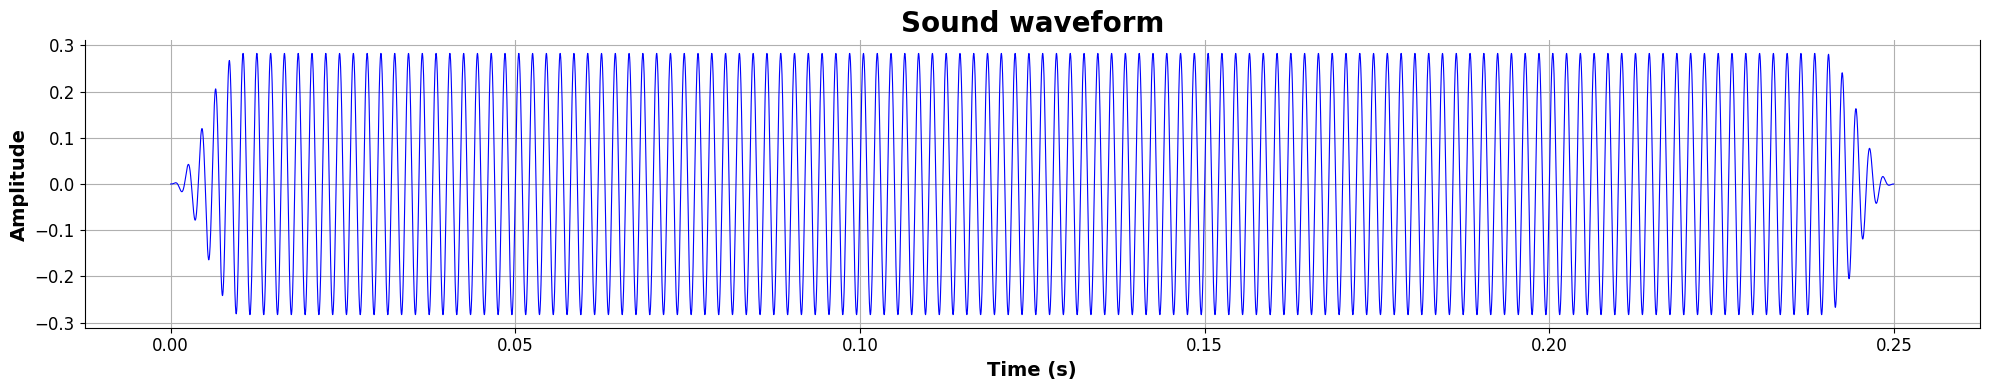

In [4]:
sound = Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level)
binaural, g = run_hrtf(sound, 0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
plot_sound(g)

2025-11-25 15:55:48,505 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:55:48,506 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:48,506 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:48,538 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:48,541 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:55:48,541 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:48,541 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:48,566 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:48,570 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:55:48,570 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:48,570 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:48,595 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:48,598 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:55:48,598 [DEBUG]  [run_hrtf] A

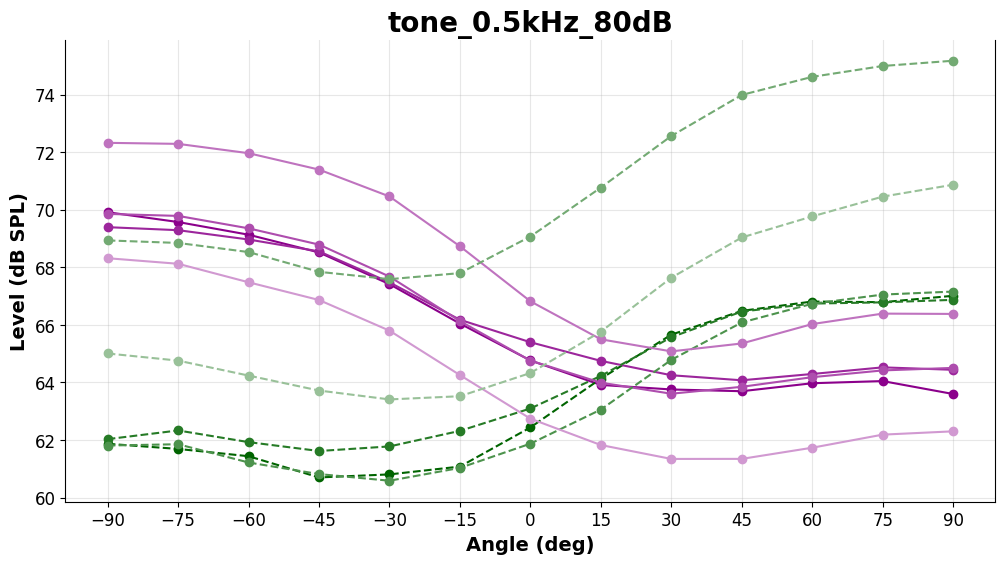

2025-11-25 15:55:50,681 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:55:50,681 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:50,681 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:50,711 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:50,716 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:55:50,716 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:50,716 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:50,747 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:50,754 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:55:50,755 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:50,755 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:50,782 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:50,789 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:55:50,789 [DEBUG]  [run_hrtf] A

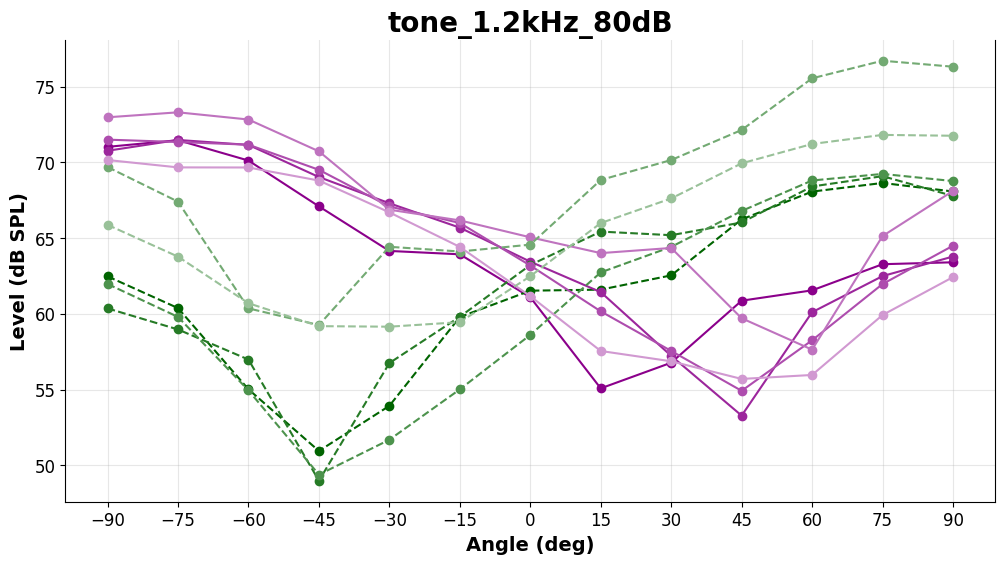

2025-11-25 15:55:52,933 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:55:52,933 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:52,934 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:52,965 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:52,971 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:55:52,971 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:52,971 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:52,999 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:53,008 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:55:53,008 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:53,008 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:53,040 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:53,048 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:55:53,048 [DEBUG]  [run_hrtf] A

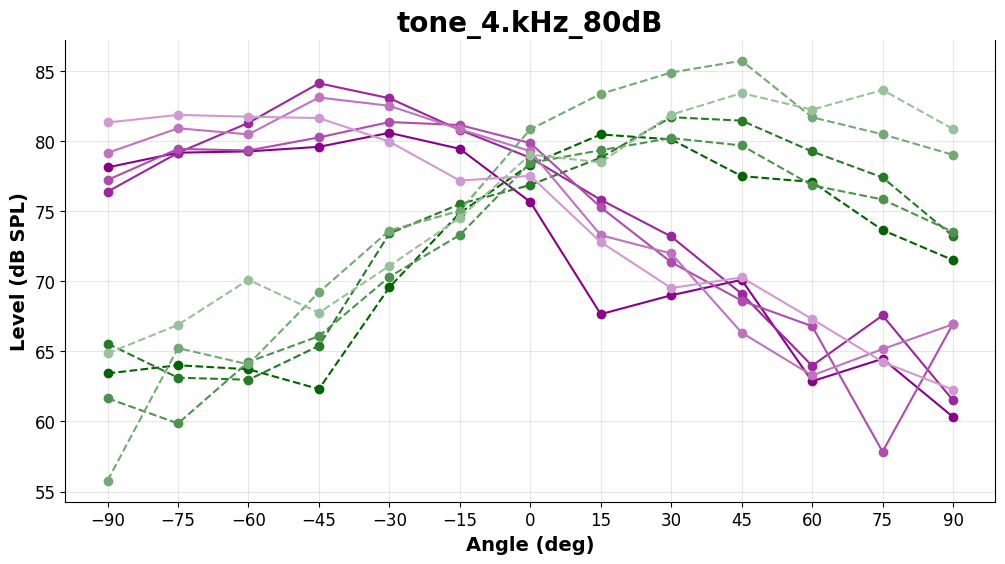

2025-11-25 15:55:55,122 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:55:55,122 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:55,123 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:55,150 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:55,157 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:55:55,157 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:55,157 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:55,183 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:55,191 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:55:55,192 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:55,192 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:55,220 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:55,224 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:55:55,224 [DEBUG]  [run_hrtf] A

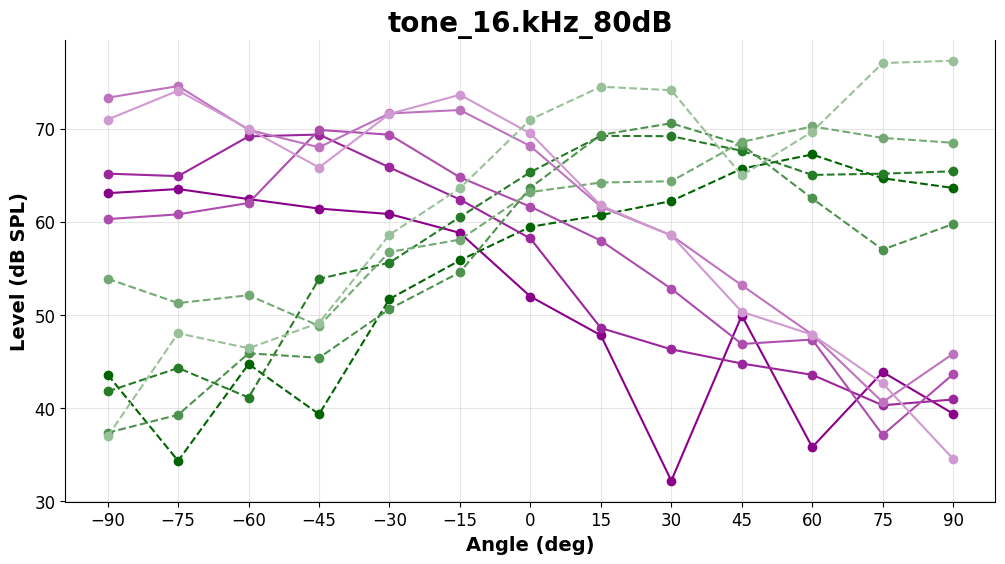

2025-11-25 15:55:57,248 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:55:57,248 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:57,248 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:57,273 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:57,278 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:55:57,278 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:57,278 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:57,304 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:57,309 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:55:57,309 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-11-25 15:55:57,309 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:55:57,333 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:55:57,336 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:55:57,336 [DEBUG]  [run_hrtf] A

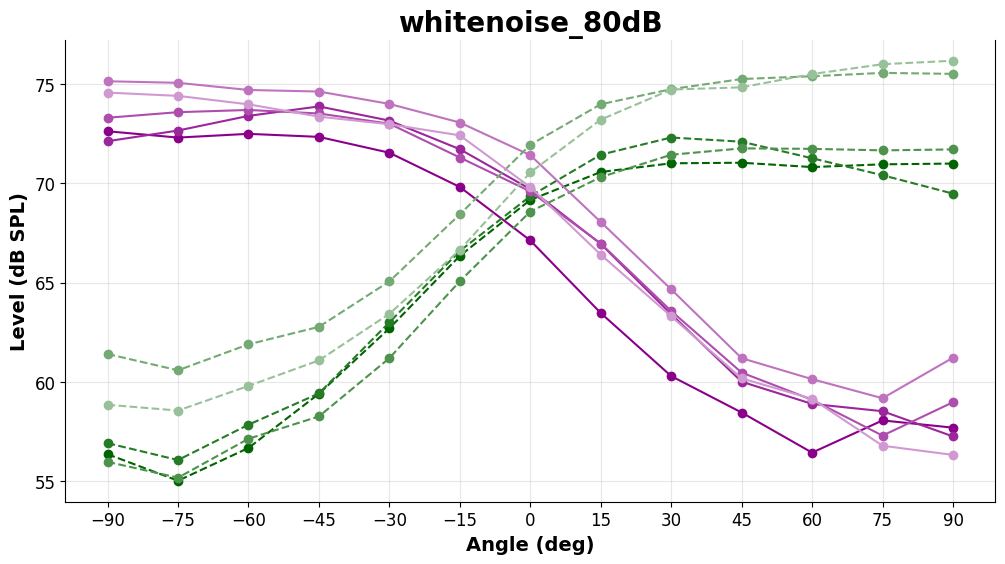

In [23]:
subjects = range(5)

# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

for sound in inputs:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o--",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2025-11-24 16:07:44,357 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:07:44,357 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:07:44,405 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:07:44,407 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:07:44,407 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:07:44,429 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:07:44,431 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:07:44,431 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:07:44,453 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:07:44,455 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:07:44,455 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:07:44,477 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:07:44,479 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:07:44,479 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB

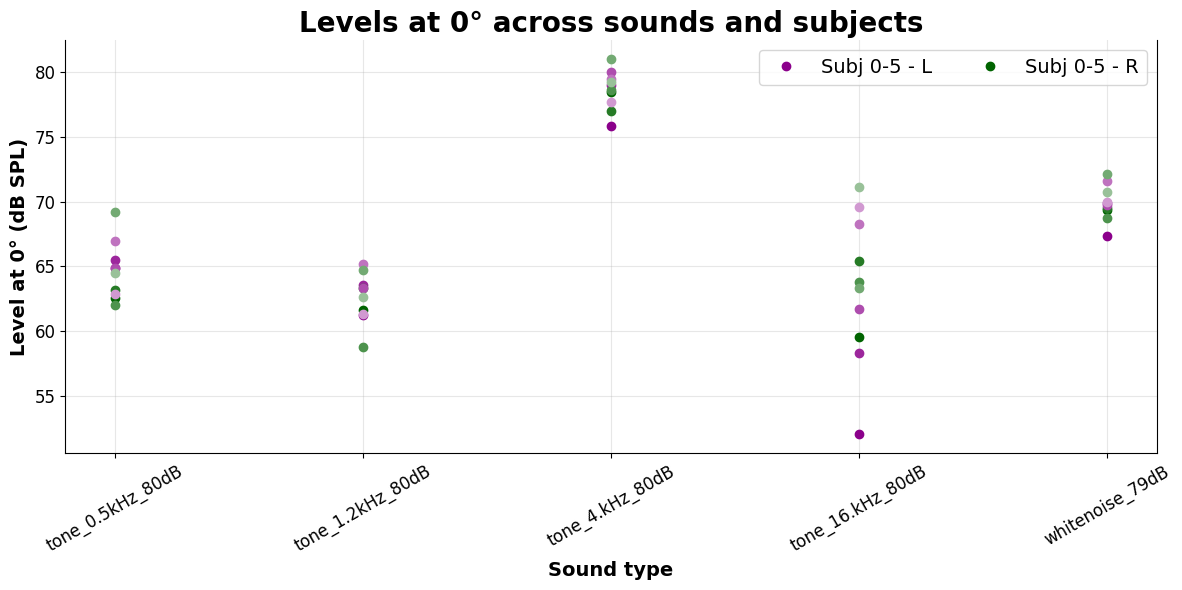

In [15]:
# pick the angle you want to isolate
ANGLE0 = 0

plt.figure(figsize=(12, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-5 - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-5 - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


2025-11-24 15:55:17,693 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 15:55:17,695 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:17,728 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:17,731 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 15:55:17,731 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:17,757 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:17,759 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 15:55:17,759 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:17,785 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:17,787 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 15:55:17,787 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:17,810 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:17,812 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 15:55:17,812 [DEBUG]  [run_hrtf] Using IRC

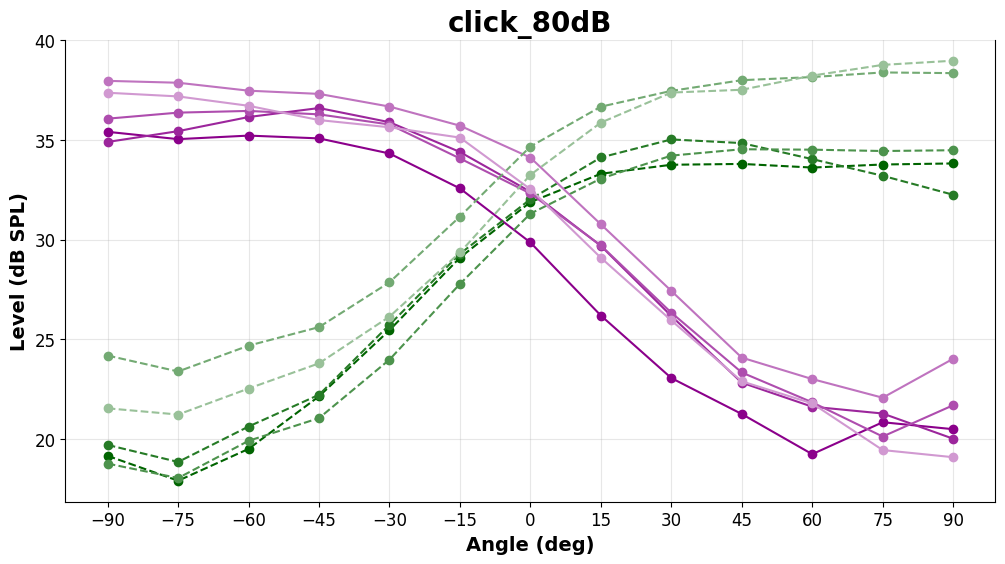

2025-11-24 15:55:19,783 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 15:55:19,784 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:19,812 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:19,816 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 15:55:19,816 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:19,839 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:19,843 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 15:55:19,843 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:19,867 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:19,871 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 15:55:19,871 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 15:55:19,895 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 15:55:19,899 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 15:55:19,899 [DEBUG]  [run_hrtf] Using IRC

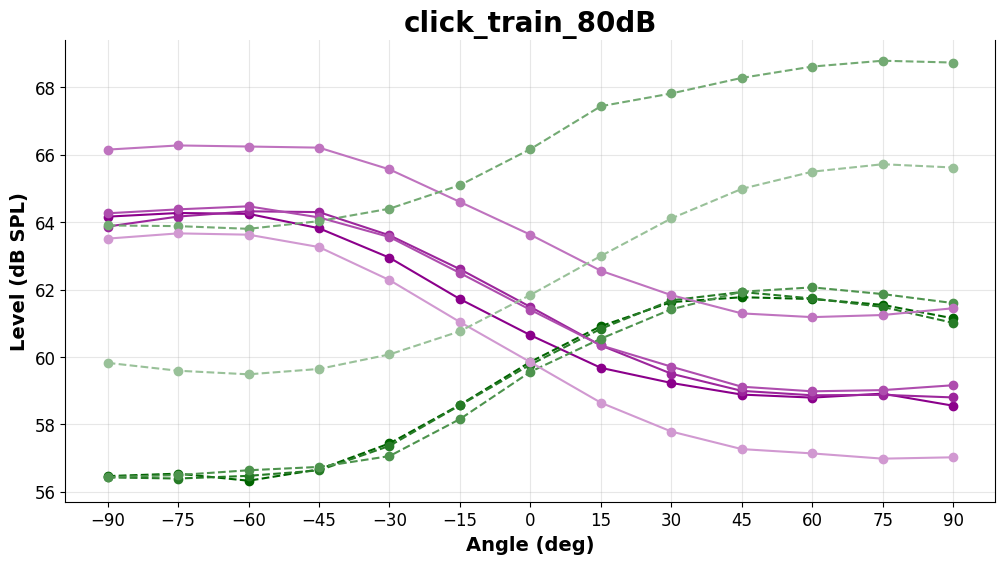

In [6]:
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

for sound in inputs_2:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['apply_gating'] = False
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o--",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()

2025-11-24 10:53:39,658 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 10:53:39,659 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:39,692 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:39,696 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 10:53:39,696 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:39,720 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:39,722 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 10:53:39,723 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:39,745 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:39,748 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 10:53:39,748 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:39,771 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:39,774 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 10:53:39,774 [DEBUG]  [run_hrtf] Using IRC

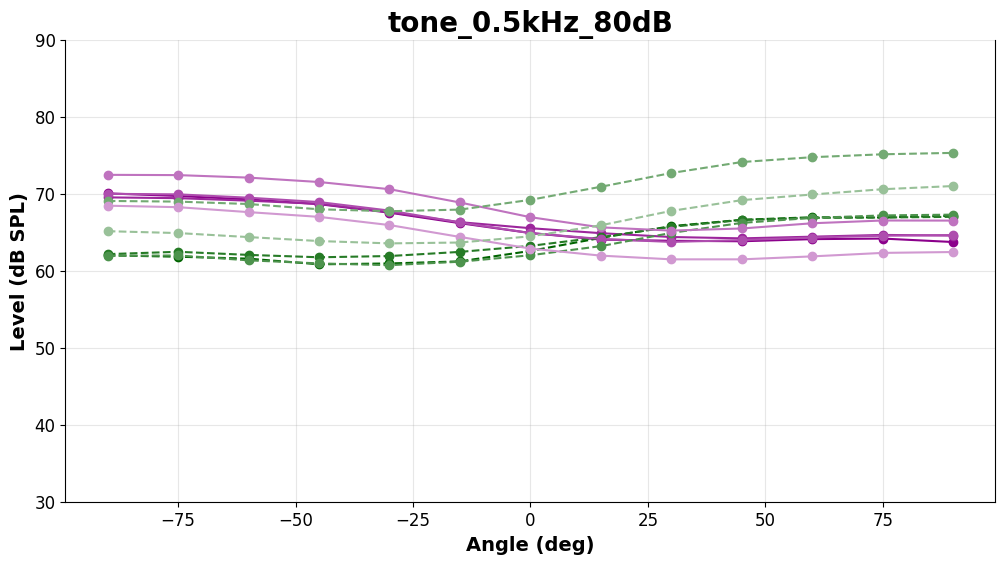

2025-11-24 10:53:41,533 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 10:53:41,533 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:41,557 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:41,559 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 10:53:41,559 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:41,581 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:41,585 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 10:53:41,585 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:41,607 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:41,610 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 10:53:41,610 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:41,633 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:41,636 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 10:53:41,636 [DEBUG]  [run_hrtf] Using IRC

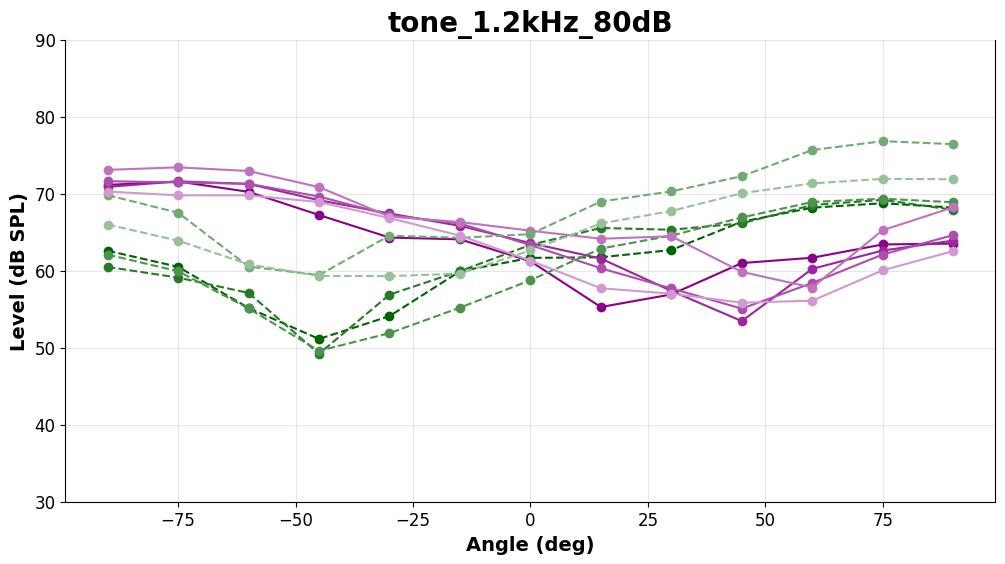

2025-11-24 10:53:43,365 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 10:53:43,365 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:43,391 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:43,397 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 10:53:43,397 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:43,422 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:43,425 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 10:53:43,426 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:43,450 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:43,454 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 10:53:43,454 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:43,476 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:43,480 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 10:53:43,480 [DEBUG]  [run_hrtf] Using IRC

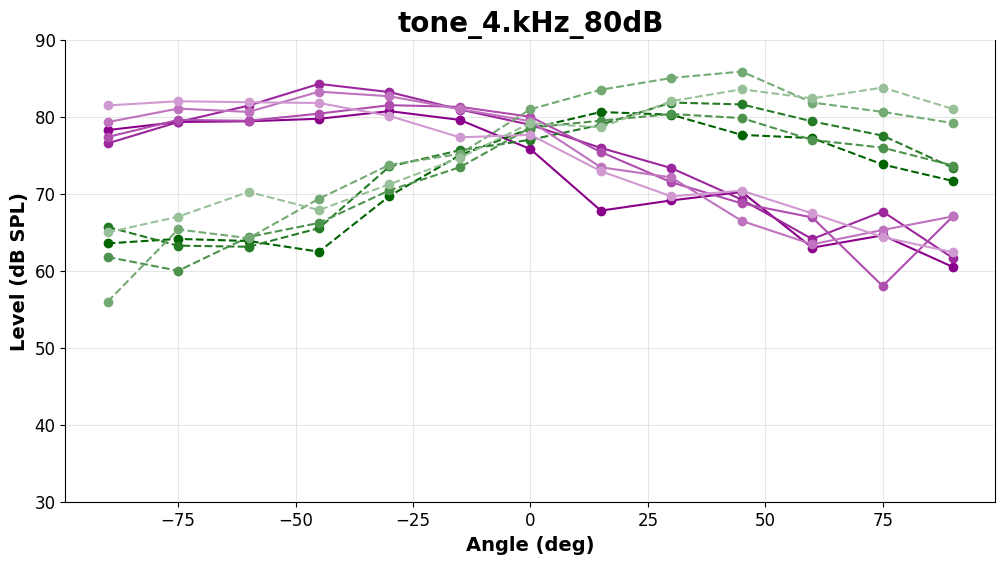

2025-11-24 10:53:45,117 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 10:53:45,117 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:45,141 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:45,144 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 10:53:45,144 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:45,165 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:45,167 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 10:53:45,167 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:45,190 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:45,193 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 10:53:45,194 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:45,215 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:45,220 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 10:53:45,220 [DEBUG]  [run_hrtf] Using IRC

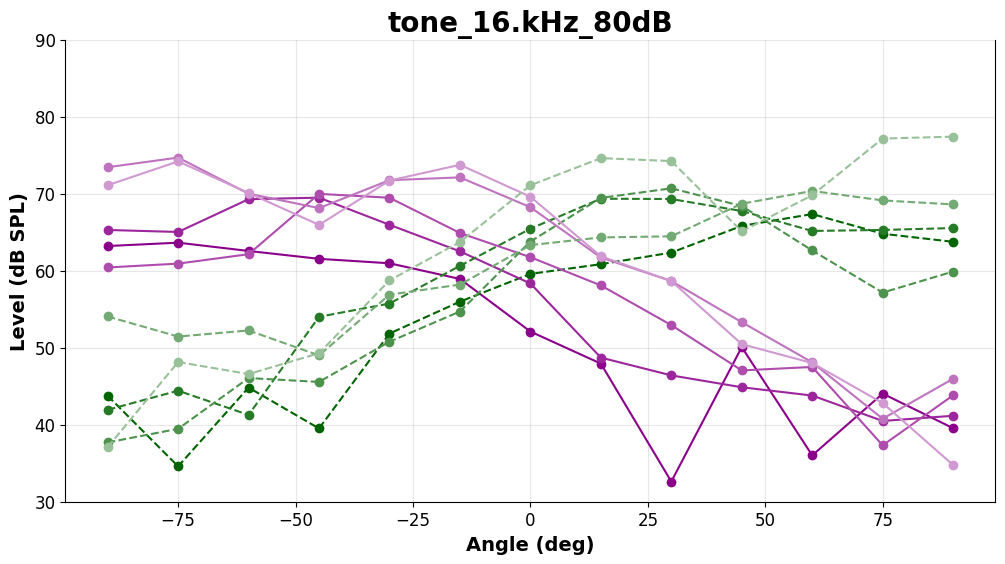

2025-11-24 10:53:46,848 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-24 10:53:46,848 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:46,871 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:46,874 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-24 10:53:46,874 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:46,897 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:46,900 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-24 10:53:46,901 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:46,923 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:46,926 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-24 10:53:46,926 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 10:53:46,950 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 10:53:46,954 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-24 10:53:46,954 [DEBUG]  [run_hrtf] Using IRC

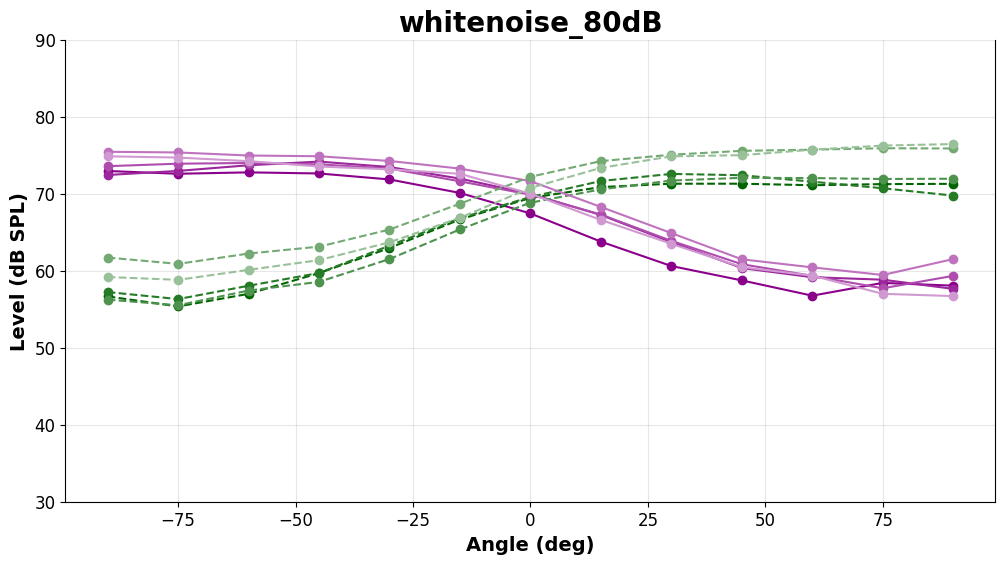

In [79]:
subjects = range(5)

# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

for sound in inputs:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o--",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.ylim([30,90])
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2025-11-24 16:11:00,214 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:11:00,217 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:11:00,288 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:11:00,295 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-11-24 16:11:00,295 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:11:00,334 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:11:00,339 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2025-11-24 16:11:00,339 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:11:00,376 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:11:00,380 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2025-11-24 16:11:00,380 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-24 16:11:00,414 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-24 16:11:00,419 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2025-11-24 16:11:00,419 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB

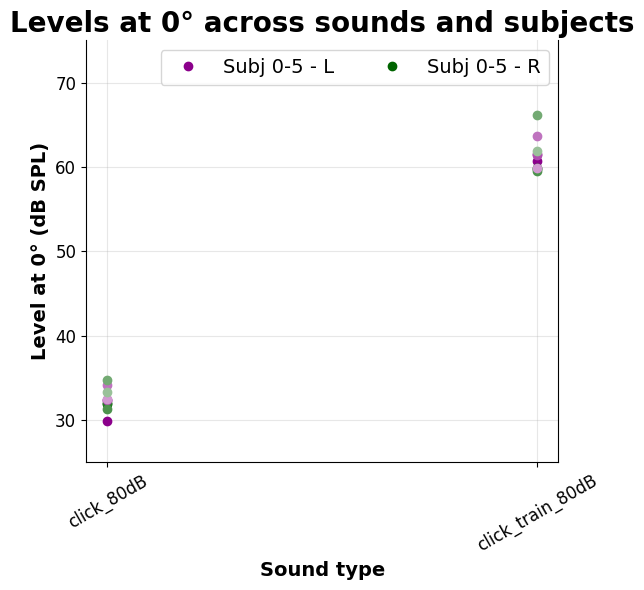

In [19]:
# pick the angle you want to isolate
ANGLE0 = 0

plt.figure(figsize=(6, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs_2]
x = np.arange(len(inputs_2))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs_2:
        p.cochlea[ZI_COC_KEY]['hrtf_params']['apply_gating'] = False
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-5 - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-5 - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.ylim([25,75])
plt.tight_layout()
plt.show()


2025-11-25 15:56:00,547 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:56:00,547 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:00,573 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:00,581 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:56:00,581 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:00,605 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:00,609 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:56:00,609 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:00,634 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:00,638 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:56:00,638 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:00,663 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:00,667 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-25 15:56:00,667 [DEBUG]  [run_hrtf] Using IRC

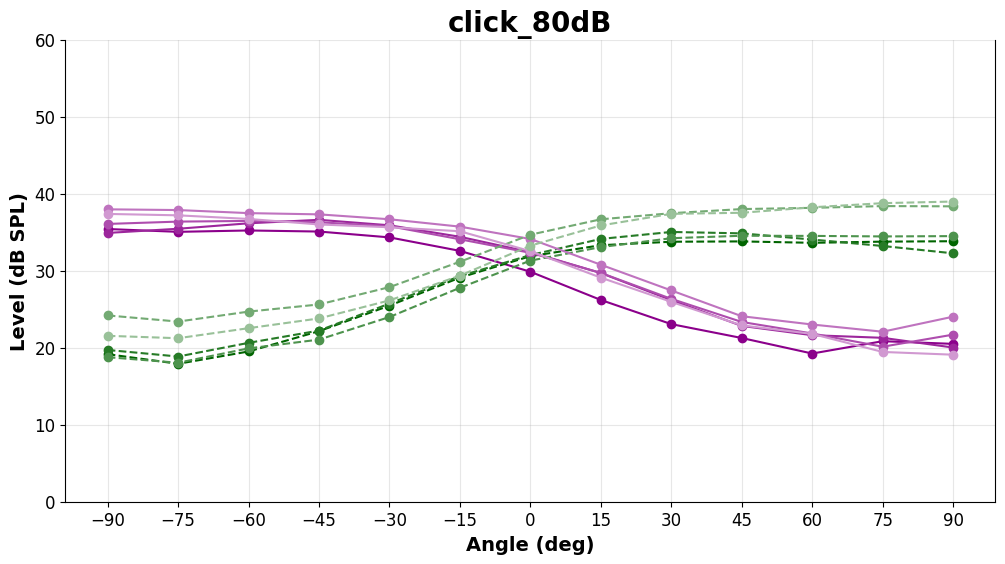

2025-11-25 15:56:02,708 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-11-25 15:56:02,710 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:02,741 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:02,748 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-11-25 15:56:02,748 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:02,773 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:02,781 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-11-25 15:56:02,781 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:02,805 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:02,807 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-11-25 15:56:02,807 [DEBUG]  [run_hrtf] Using IRCAM HRTF DB...
2025-11-25 15:56:02,832 [DEBUG]  [run_hrtf] HRTF computation complete.
2025-11-25 15:56:02,838 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-11-25 15:56:02,838 [DEBUG]  [run_hrtf] Using IRC

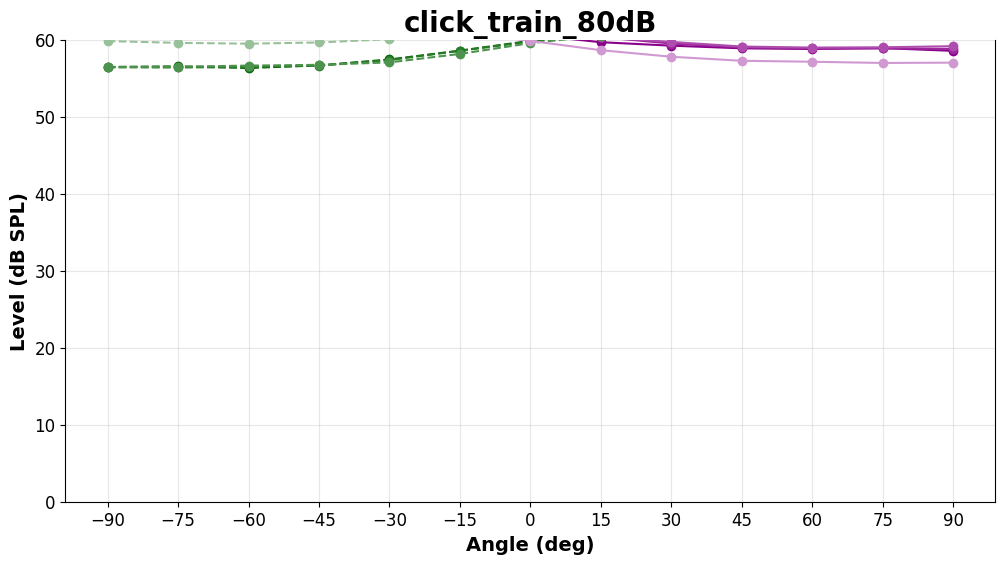

In [24]:
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

for sound in inputs_2:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['apply_gating'] = False
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o--",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    plt.ylim([0,60])
    # legend: one entry for Left and one for Right is usually enough
    plt.show()